# 01 - Prepare BP/RP Inputs

One notebook, one place.

This notebook now does the following:
- loads only `source_id` and `y` from your existing local thesis data;
- fetches **raw XP continuous data** from Gaia@AIP;
- calibrates BP and RP separately from raw Gaia continuous rows using `gaiaxpy.calibrate()`;
- saves both raw and L2-normalized BP/RP sampled spectra;
- visualizes 10 random stars.

Important:
- old local XP coefficient CSVs are **not** used as the spectral source;
- they are used only as a source of `source_id` and `y`.

In [65]:
from pathlib import Path
import ast
import io
import json
import os
import re
import time
from typing import Optional

import matplotlib
matplotlib.rcParams["text.usetex"] = False

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import pyvo as vo
from astropy.io.votable import parse_single_table
from astropy.table import Table
from gaiaxpy import calibrate

from _common import (
    BP_SAMPLED_CSV,
    DATA_DIR,
    LEGACY_OG_XP,
    RAW_CLASSIFICATION_CSV,
    ROOT,
    RP_SAMPLED_CSV,
    save_manifest,
)

plt.rcParams["text.usetex"] = False
ROOT

PosixPath('/Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment')

## Build the local source-id / label table

Only `source_id` and `y` are taken from local files.
No old XP coefficient values are used for reconstruction.

In [66]:
if LEGACY_OG_XP.exists():
    df_local = pd.read_csv(LEGACY_OG_XP, usecols=["source_id", "y"])
else:
    df_local = pd.read_csv(RAW_CLASSIFICATION_CSV, usecols=["source_id", "y"])

label_df = df_local.copy()
label_df["source_id"] = pd.to_numeric(label_df["source_id"], errors="coerce").astype("Int64")
label_df = label_df.dropna(subset=["source_id"]).copy()
label_df["source_id"] = label_df["source_id"].astype("int64")
label_df["y"] = label_df["y"].astype(int)
label_df = label_df.drop_duplicates("source_id").reset_index(drop=True)

label_df.head()

,source_id,y
0,1792620565667968,0
1,6052403489630720,0
2,10844075163628928,0
3,11015044926034816,0
4,11963171843658240,0


In [67]:
print("Rows:", len(label_df))
print("Class balance:", label_df["y"].value_counts().to_dict())

Rows: 2815
Class balance: {0: 2257, 1: 558}


## Gaia@AIP config

In [68]:
GAIA_AIP_TOKEN = os.getenv("GAIA_AIP_TOKEN", "").strip()
TAP_URL = "https://gaia.aip.de/tap"
SJS_URL = "https://gaia.aip.de/uws/simple-join-service"

CACHE_DIR = DATA_DIR / "cache_vot"
CACHE_DIR.mkdir(exist_ok=True)

CHUNK_SIZE = 400

BP_RAW_CSV = DATA_DIR / "bp_sampled_spectra_raw.csv"
RP_RAW_CSV = DATA_DIR / "rp_sampled_spectra_raw.csv"

if not GAIA_AIP_TOKEN:
    raise RuntimeError("Set GAIA_AIP_TOKEN in your environment before running this notebook.")

sess = requests.Session()
sess.headers["Authorization"] = (
    GAIA_AIP_TOKEN if GAIA_AIP_TOKEN.startswith("Token ") else f"Token {GAIA_AIP_TOKEN}"
)

print("CACHE_DIR:", CACHE_DIR)
print("Raw BP output:", BP_RAW_CSV)
print("Raw RP output:", RP_RAW_CSV)
print("L2 BP output:", BP_SAMPLED_CSV)
print("L2 RP output:", RP_SAMPLED_CSV)

CACHE_DIR: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/cache_vot
Raw BP output: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/bp_sampled_spectra_raw.csv
Raw RP output: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/rp_sampled_spectra_raw.csv
L2 BP output: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/bp_sampled_spectra.csv
L2 RP output: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/rp_sampled_spectra.csv


## TAP/SJS helpers from the old working notebook

In [69]:
def tap_create_async_job(query: str, runid: str = "xp_chunk") -> str:
    url = f"{TAP_URL}/async"
    payload = {
        "REQUEST": "doQuery",
        "LANG": "ADQL",
        "FORMAT": "votable",
        "QUERY": query.strip().rstrip(";"),
        "RUNID": runid,
    }
    r = sess.post(url, data=payload, allow_redirects=False, timeout=120)
    if r.status_code in (302, 303) and "Location" in r.headers:
        job_url = r.headers["Location"]
        if job_url.startswith("/"):
            job_url = "https://gaia.aip.de" + job_url
    else:
        raise RuntimeError(f"Unexpected TAP response: HTTP {r.status_code}")

    sess.post(f"{job_url}/phase", data={"PHASE": "RUN"}, timeout=60).raise_for_status()

    t0 = time.time()
    while True:
        ph = sess.get(f"{job_url}/phase", timeout=60).text.strip()
        if ph in ("COMPLETED", "ERROR", "ABORTED"):
            break
        if time.time() - t0 > 300:
            raise TimeoutError("TAP async job timed out (>300 s).")
        time.sleep(2)

    if ph != "COMPLETED":
        raise RuntimeError(f"TAP job ended with phase={ph}")
    return job_url.rstrip("/").split("/")[-1]

def sjs_download(job_id: str, join_table: str, tag: str = "result") -> Path:
    service = vo.dal.DALService(SJS_URL, session=sess)
    q = service.create_query(
        job_id=job_id,
        column_name="source_id",
        responseformat="votable",
        join_table=join_table,
        data_structure="COMBINED",
    )
    resp = q.submit(post=True)
    resp.raise_for_status()
    job = vo.io.uws.parse_job(io.BytesIO(resp.content))

    service._session.post(
        f"{service._baseurl}/{job.jobid}/phase",
        data={"PHASE": "RUN"}, stream=True,
    ).raise_for_status()

    t0 = time.time()
    while True:
        ph = service._session.get(f"{service._baseurl}/{job.jobid}/phase").text.strip()
        if ph in ("COMPLETED", "ERROR", "ABORTED"):
            break
        if time.time() - t0 > 360:
            raise TimeoutError("SJS job timed out (>360 s).")
        time.sleep(2)

    if ph != "COMPLETED":
        raise RuntimeError(f"SJS ended with phase={ph}")

    job_url = f"{service._baseurl}/{job.jobid}"
    job2 = vo.io.uws.parse_job(io.BytesIO(service._session.get(job_url).content))
    results = job2.results

    if hasattr(results, "keys") and callable(getattr(results, "keys")):
        first_key = sorted(list(results.keys()))[0]
        href = results[first_key].href
    else:
        res_list = list(results)
        if not res_list:
            raise RuntimeError("SJS job has no results.")
        href = res_list[0].href

    out_path = CACHE_DIR / f"sjs_{tag}.vot"
    out_path.write_bytes(service._session.get(href, timeout=300).content)
    return out_path

## Download XP continuous rows from Gaia@AIP

In [70]:
source_ids = label_df["source_id"].tolist()
join_table = "gaiadr3.xp_continuous_mean_spectrum"
vot_paths = sorted(CACHE_DIR.glob("sjs_chunk_*.vot"))

if vot_paths:
    print(f"Using {len(vot_paths)} cached VOTable(s) from {CACHE_DIR}")
else:
    n_chunks = (len(source_ids) + CHUNK_SIZE - 1) // CHUNK_SIZE
    print(f"Downloading XP coefficients: {len(source_ids)} sources in {n_chunks} chunks")

    for i in range(0, len(source_ids), CHUNK_SIZE):
        chunk_idx = i // CHUNK_SIZE
        chunk = source_ids[i : i + CHUNK_SIZE]
        ids_sql = ",".join(str(int(sid)) for sid in chunk)
        query = f"SELECT source_id FROM gaiadr3.gaia_source WHERE source_id IN ({ids_sql})"

        print(f"Chunk {chunk_idx + 1}/{n_chunks}: {len(chunk)} sources")
        job_id = tap_create_async_job(query, runid=f"xp_chunk_{chunk_idx:04d}")
        vot_path = sjs_download(job_id, join_table, tag=f"chunk_{chunk_idx:04d}")
        print("  Saved:", vot_path)

    vot_paths = sorted(CACHE_DIR.glob("sjs_chunk_*.vot"))

print("Total VOTable files:", len(vot_paths))

Using 8 cached VOTable(s) from /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/cache_vot
Total VOTable files: 8


## Parse fetched XP rows

In [71]:
def to_1d_float(x, expected_len: Optional[int] = None) -> np.ndarray:
    if isinstance(x, np.ma.MaskedArray):
        x = np.ma.getdata(x)
    if isinstance(x, str):
        s = x.strip()
        try:
            x = ast.literal_eval(s)
        except Exception:
            s = s.strip("[]()")
            parts = re.split(r"[,\s]+", s)
            parts = [p for p in parts if p]
            x = [float(p) for p in parts]
    arr = np.asarray(x, dtype=float).reshape(-1)
    if expected_len is not None and arr.size != expected_len:
        raise ValueError(f"Expected len={expected_len}, got {arr.size}")
    return arr

dfs_raw = []
for p in vot_paths:
    df_x = Table.read(str(p)).to_pandas()
    if "source_id" not in df_x.columns and "datalinkID" in df_x.columns:
        df_x["source_id"] = (
            df_x["datalinkID"].astype(str).str.extract(r"(\d{10,})")[0].astype("int64")
        )
    df_x["source_id"] = df_x["source_id"].astype("int64")
    dfs_raw.append(df_x)

df_xp = pd.concat(dfs_raw, ignore_index=True).drop_duplicates("source_id")
df_xp = df_xp[df_xp["source_id"].isin(source_ids)].copy()

keep_cols = [
    "source_id",
    "bp_n_parameters", "bp_standard_deviation",
    "bp_coefficients", "bp_coefficient_errors", "bp_coefficient_correlations",
    "rp_n_parameters", "rp_standard_deviation",
    "rp_coefficients", "rp_coefficient_errors", "rp_coefficient_correlations",
]
df_xp = df_xp[keep_cols].copy()

for col in ["source_id", "bp_n_parameters", "rp_n_parameters"]:
    df_xp[col] = pd.to_numeric(df_xp[col], errors="coerce")
for col in ["bp_standard_deviation", "rp_standard_deviation"]:
    df_xp[col] = pd.to_numeric(df_xp[col], errors="coerce")
df_xp = df_xp.dropna(subset=["source_id"]).copy()
df_xp["source_id"] = df_xp["source_id"].astype("int64")

print("XP rows fetched:", len(df_xp), "out of", len(source_ids))
df_xp.head()

XP rows fetched: 2815 out of 2815


,source_id,bp_n_parameters,bp_standard_deviation,bp_coefficients,bp_coefficient_errors,bp_coefficient_correlations,rp_n_parameters,rp_standard_deviation,rp_coefficients,rp_coefficient_errors,rp_coefficient_correlations
0,1792620565667968,55,1.040061,"[570.1485492681098, -319.3298228092743, 102.82...","[1.1740507, 1.1106362, 1.0757829, 1.1683774, 1...","[-0.059719767, -0.1416985, -0.07887346, -0.005...",55,1.047611,"[241.40836196049574, -82.69827450064226, -14.3...","[0.5663346, 0.5479432, 0.5312016, 0.60421115, ...","[-0.18805803, 0.107046746, 0.21842356, -0.0216..."
1,6052403489630720,55,1.043667,"[3277.3159296451317, -1867.441581766939, 606.7...","[2.959191, 2.9159465, 2.8412952, 3.0713444, 3....","[-0.107505865, -0.09834415, -0.18096873, -0.00...",55,1.037614,"[1348.9404539797583, -476.52148742371384, -87....","[1.2591143, 1.2215121, 1.1482905, 1.2723544, 1...","[-0.25532818, 0.11068409, 0.31008282, -0.03051..."
2,10844075163628928,55,1.057270,"[821.1203744972646, -361.12618397593775, 91.60...","[1.3896443, 1.3136474, 1.2310404, 1.3386704, 1...","[-0.05970565, -0.13554575, -0.046883743, 0.004...",55,1.036942,"[446.21486935141263, -125.50342725101679, -19....","[0.7449101, 0.71896076, 0.689311, 0.78774744, ...","[-0.20130388, 0.11189627, 0.22242299, -0.02018..."
3,11015044926034816,55,1.055573,"[595.8118296281822, -287.52170934154066, 82.07...","[1.2987702, 1.2502341, 1.1398518, 1.2519614, 1...","[-0.09633489, -0.12089616, -0.036737494, 0.042...",55,1.072268,"[296.66817870082747, -90.57569518562141, -15.1...","[0.6957543, 0.6750194, 0.6508078, 0.7360824, 0...","[-0.13149138, 0.09221556, 0.18898535, -0.01769..."
4,11963171843658240,55,1.039469,"[579.9012867993417, -254.64085369234252, 65.50...","[1.14367, 1.0524672, 1.0216397, 1.1103379, 1.1...","[-0.02729982, -0.15694691, -0.025218047, 0.000...",55,1.028730,"[315.5405627672473, -89.30964787987861, -14.24...","[0.44152948, 0.41921517, 0.41077217, 0.4518531...","[-0.14904968, 0.12983671, 0.17356586, -0.01391..."


## Separate BP/RP calibration via `gaiaxpy.calibrate`

This uses the raw Gaia continuous data directly and keeps the two arms separate by masking the opposite arm before calibration.

This version gives physical wavelength in nm on the x-axis.

How the separation works:
- for the BP table, all RP spectral fields are set to `NaN`, so GaiaXPy treats RP as missing;
- for the RP table, all BP spectral fields are set to `NaN`, so GaiaXPy treats BP as missing;
- GaiaXPy then calibrates each arm onto the standard wavelength grid and masks the unavailable region.

In [72]:
CALIBRATE_COLS = [
    "source_id",
    "bp_n_parameters", "bp_standard_deviation",
    "bp_coefficients", "bp_coefficient_errors", "bp_coefficient_correlations",
    "rp_n_parameters", "rp_standard_deviation",
    "rp_coefficients", "rp_coefficient_errors", "rp_coefficient_correlations",
]

def make_band_only_input(df: pd.DataFrame, band: str) -> pd.DataFrame:
    if band not in {"bp", "rp"}:
        raise ValueError("band must be 'bp' or 'rp'")
    other = "rp" if band == "bp" else "bp"
    out = df[CALIBRATE_COLS].copy()
    out[f"{other}_standard_deviation"] = np.nan
    out[f"{other}_coefficients"] = np.nan
    out[f"{other}_coefficient_errors"] = np.nan
    out[f"{other}_coefficient_correlations"] = np.nan
    return out

def calibrated_flux_frame(df_band: pd.DataFrame, prefix: str):
    calibrated_df, sampling = calibrate(df_band, save_file=False, with_correlation=False)
    flux = np.vstack([to_1d_float(x) for x in calibrated_df["flux"]])
    wl_cols = [f"wl_{wl:.0f}" for wl in sampling]
    out = pd.DataFrame(flux, columns=wl_cols)
    out.insert(0, "source_id", calibrated_df["source_id"].astype("int64").to_numpy())
    valid = ~np.all(np.isnan(flux), axis=0)
    band_cols = [col for col, keep in zip(wl_cols, valid) if keep]
    if not band_cols:
        raise RuntimeError(f"No valid wavelength columns found for {prefix}.")
    out = out[["source_id"] + band_cols]
    return out, np.asarray([float(c.split("_", 1)[1]) for c in band_cols], dtype=float)

df_bp_input = make_band_only_input(df_xp, "bp")
df_rp_input = make_band_only_input(df_xp, "rp")

df_bp_flux, bp_wavelengths = calibrated_flux_frame(df_bp_input, "bp")
df_rp_flux, rp_wavelengths = calibrated_flux_frame(df_rp_input, "rp")

df_bp_sampled_raw = label_df.merge(df_bp_flux, on="source_id", how="inner")
df_rp_sampled_raw = label_df.merge(df_rp_flux, on="source_id", how="inner")

print("BP raw shape:", df_bp_sampled_raw.shape)
print("RP raw shape:", df_rp_sampled_raw.shape)
print(f"BP wavelength range: {bp_wavelengths[0]:.0f}-{bp_wavelengths[-1]:.0f} nm ({len(bp_wavelengths)} bins)")
print(f"RP wavelength range: {rp_wavelengths[0]:.0f}-{rp_wavelengths[-1]:.0f} nm ({len(rp_wavelengths)} bins)")

BP raw shape: (2815, 156)                                                 00:00, 16930.49spec/s]
RP raw shape: (2815, 195)
BP wavelength range: 336-642 nm (154 bins)
RP wavelength range: 636-1020 nm (193 bins)


## L2-normalize the sampled BP and RP spectra row-wise

In [73]:
def l2_normalize_sampled_df(df: pd.DataFrame) -> pd.DataFrame:
    spec_cols = [c for c in df.columns if c.startswith("wl_")]
    X = df[spec_cols].to_numpy(dtype=float)
    norms = np.sqrt(np.nansum(X ** 2, axis=1, keepdims=True))
    norms = np.where(norms > 0, norms, 1.0)
    out = df.copy()
    Xn = X / norms
    Xn[np.isnan(X)] = np.nan
    out[spec_cols] = Xn
    return out

df_bp_sampled = l2_normalize_sampled_df(df_bp_sampled_raw)
df_rp_sampled = l2_normalize_sampled_df(df_rp_sampled_raw)

display(df_bp_sampled.head())
display(df_rp_sampled.head())

,source_id,y,wl_336,wl_338,wl_340,wl_342,wl_344,wl_346,wl_348,wl_350,...,wl_624,wl_626,wl_628,wl_630,wl_632,wl_634,wl_636,wl_638,wl_640,wl_642
0,1792620565667968,0,0.159157,0.168624,0.165189,0.154861,0.150021,0.152673,0.158793,0.159235,...,0.023292,0.023310,0.023366,0.023438,0.023450,0.023459,0.023377,0.023196,0.022952,0.022548
1,6052403489630720,0,0.166592,0.173453,0.173400,0.168563,0.164615,0.158843,0.151080,0.144904,...,0.022190,0.022057,0.021974,0.021921,0.021833,0.021762,0.021629,0.021425,0.021184,0.020816
2,10844075163628928,0,0.122596,0.121428,0.130249,0.130430,0.125371,0.126716,0.135263,0.136324,...,0.035158,0.034725,0.034386,0.034130,0.033859,0.033665,0.033430,0.033141,0.032848,0.032407
3,11015044926034816,0,0.171869,0.155096,0.144636,0.143698,0.140969,0.128892,0.119026,0.124846,...,0.030677,0.030482,0.030316,0.030165,0.029945,0.029739,0.029450,0.029071,0.028657,0.028091
4,11963171843658240,0,0.146855,0.151058,0.142251,0.134196,0.130277,0.129581,0.135146,0.141282,...,0.033184,0.032997,0.032895,0.032853,0.032768,0.032718,0.032585,0.032352,0.032067,0.031590


,source_id,y,wl_636,wl_638,wl_640,wl_642,wl_644,wl_646,wl_648,wl_650,...,wl_1002,wl_1004,wl_1006,wl_1008,wl_1010,wl_1012,wl_1014,wl_1016,wl_1018,wl_1020
0,1792620565667968,0,0.155415,0.157159,0.148284,0.132603,0.114247,0.106071,0.112490,0.127485,...,0.038746,0.041243,0.043203,0.042955,0.041521,0.038437,0.032950,0.026885,0.019070,0.011605
1,6052403489630720,0,0.144494,0.143646,0.143779,0.145551,0.143301,0.139308,0.135819,0.133211,...,0.026440,0.027264,0.028468,0.029098,0.029927,0.030687,0.030625,0.031088,0.030251,0.029916
2,10844075163628928,0,0.129557,0.129926,0.131115,0.133667,0.131776,0.126914,0.121343,0.116574,...,0.035044,0.031285,0.027150,0.022151,0.017567,0.013728,0.010982,0.010464,0.012000,0.016549
3,11015044926034816,0,0.134067,0.124870,0.120184,0.122028,0.124850,0.127219,0.127901,0.126342,...,0.009992,0.014511,0.022068,0.031518,0.042721,0.054492,0.064080,0.072740,0.074980,0.073865
4,11963171843658240,0,0.131752,0.130885,0.129394,0.129367,0.127167,0.124952,0.123293,0.120845,...,0.038567,0.039723,0.041240,0.041791,0.042538,0.043119,0.042505,0.042592,0.040894,0.039916


## Visualize 10 random stars: raw spectra

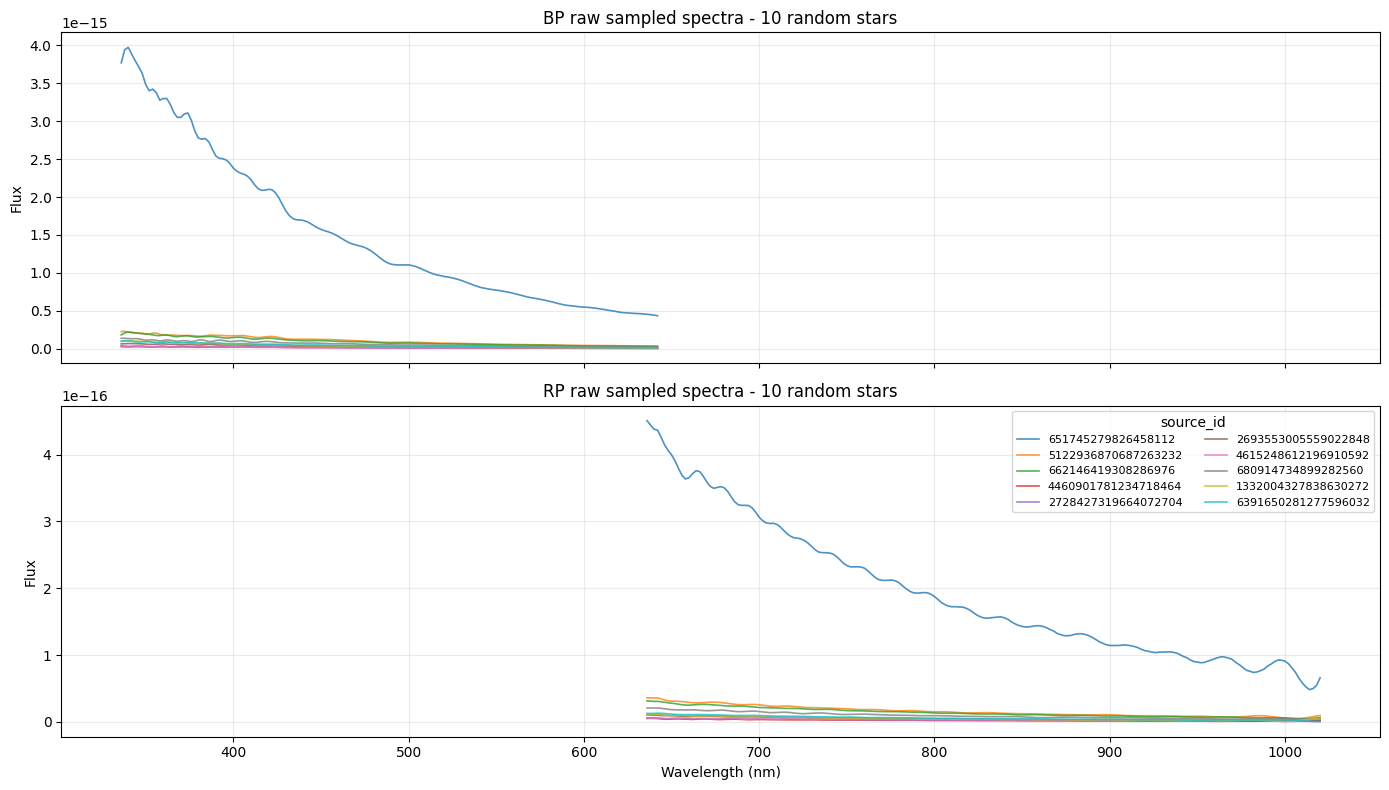

array([ 651745279826458112, 5122936870687263232,  662146419308286976,
       4460901781234718464, 2728427319664072704, 2693553005559022848,
       4615248612196910592,  680914734899282560, 1332004327838630272,
       6391650281277596032])

In [74]:
plt.rcParams["text.usetex"] = False

rng = np.random.default_rng(42)
sample_n = min(10, len(df_bp_sampled_raw), len(df_rp_sampled_raw))
sample_ids = rng.choice(df_bp_sampled_raw["source_id"].to_numpy(), size=sample_n, replace=False)

bp_cols = [c for c in df_bp_sampled_raw.columns if c.startswith("wl_")]
rp_cols = [c for c in df_rp_sampled_raw.columns if c.startswith("wl_")]
wl_bp = np.array([float(c.split("_", 1)[1]) for c in bp_cols])
wl_rp = np.array([float(c.split("_", 1)[1]) for c in rp_cols])

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for sid in sample_ids:
    bp_row = df_bp_sampled_raw.loc[df_bp_sampled_raw["source_id"] == sid, bp_cols].iloc[0].to_numpy(dtype=float)
    rp_row = df_rp_sampled_raw.loc[df_rp_sampled_raw["source_id"] == sid, rp_cols].iloc[0].to_numpy(dtype=float)
    axes[0].plot(wl_bp, bp_row, alpha=0.8, linewidth=1.2, label=str(sid))
    axes[1].plot(wl_rp, rp_row, alpha=0.8, linewidth=1.2, label=str(sid))

axes[0].set_title("BP raw sampled spectra - 10 random stars")
axes[0].set_ylabel("Flux")
axes[0].grid(True, alpha=0.25)
axes[1].set_title("RP raw sampled spectra - 10 random stars")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Flux")
axes[1].grid(True, alpha=0.25)
axes[1].legend(title="source_id", fontsize=8, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

sample_ids

## Visualize the same 10 stars: L2-normalized spectra

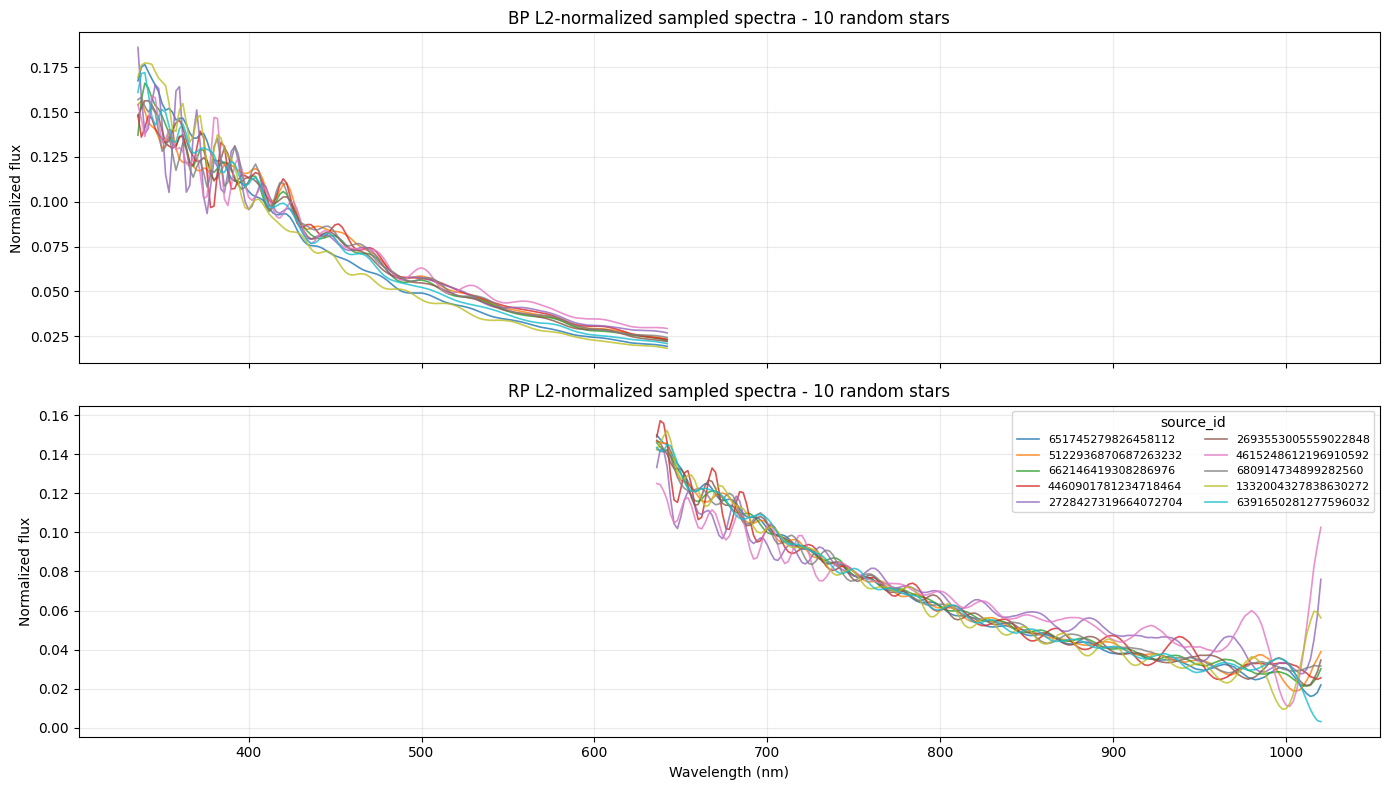

In [75]:
plt.rcParams["text.usetex"] = False

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for sid in sample_ids:
    bp_row = df_bp_sampled.loc[df_bp_sampled["source_id"] == sid, bp_cols].iloc[0].to_numpy(dtype=float)
    rp_row = df_rp_sampled.loc[df_rp_sampled["source_id"] == sid, rp_cols].iloc[0].to_numpy(dtype=float)
    axes[0].plot(wl_bp, bp_row, alpha=0.8, linewidth=1.2, label=str(sid))
    axes[1].plot(wl_rp, rp_row, alpha=0.8, linewidth=1.2, label=str(sid))

axes[0].set_title("BP L2-normalized sampled spectra - 10 random stars")
axes[0].set_ylabel("Normalized flux")
axes[0].grid(True, alpha=0.25)
axes[1].set_title("RP L2-normalized sampled spectra - 10 random stars")
axes[1].set_xlabel("Wavelength (nm)")
axes[1].set_ylabel("Normalized flux")
axes[1].grid(True, alpha=0.25)
axes[1].legend(title="source_id", fontsize=8, ncol=2, loc="upper right")
plt.tight_layout()
plt.show()

## Visualize all stars: L2-normalized spectra colored by class

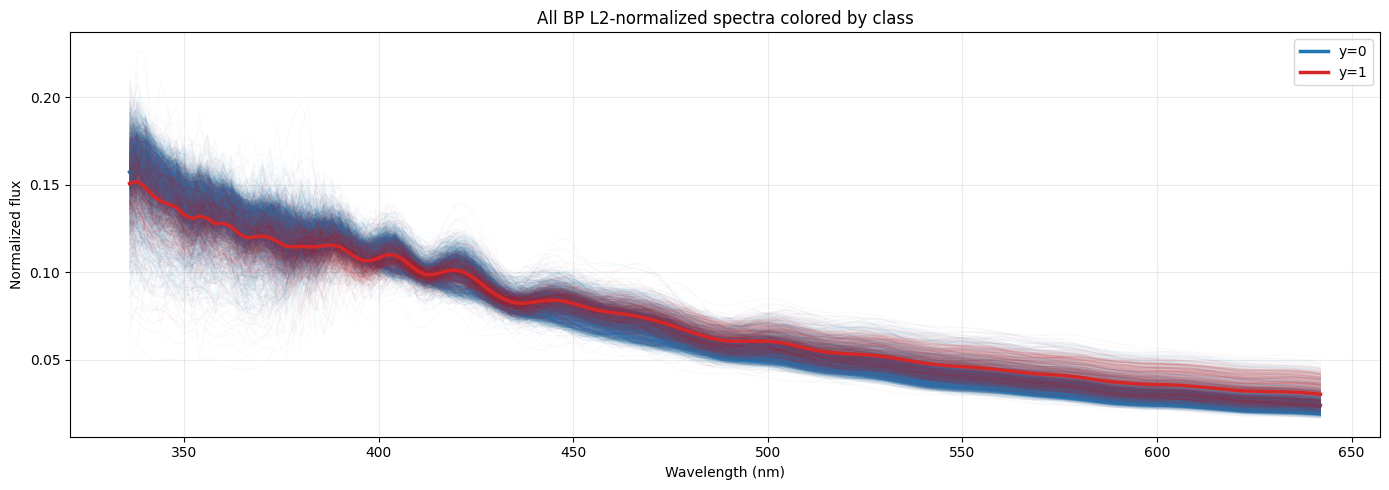

In [77]:
plt.rcParams["text.usetex"] = False

class_colors = {0: "#1f77b4", 1: "#d62728"}
class_labels = {0: "y=0", 1: "y=1"}

fig, ax = plt.subplots(figsize=(14, 5))
for cls in sorted(df_bp_sampled["y"].dropna().unique()):
    rows = df_bp_sampled[df_bp_sampled["y"] == cls]
    X = rows[bp_cols].to_numpy(dtype=float)
    for row in X:
        ax.plot(wl_bp, row, color=class_colors.get(int(cls), "#7f7f7f"), alpha=0.03, linewidth=0.8)
    mean_row = np.nanmean(X, axis=0)
    ax.plot(wl_bp, mean_row, color=class_colors.get(int(cls), "#7f7f7f"), linewidth=2.5, label=class_labels.get(int(cls), str(cls)))

ax.set_title("All BP L2-normalized spectra colored by class")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized flux")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

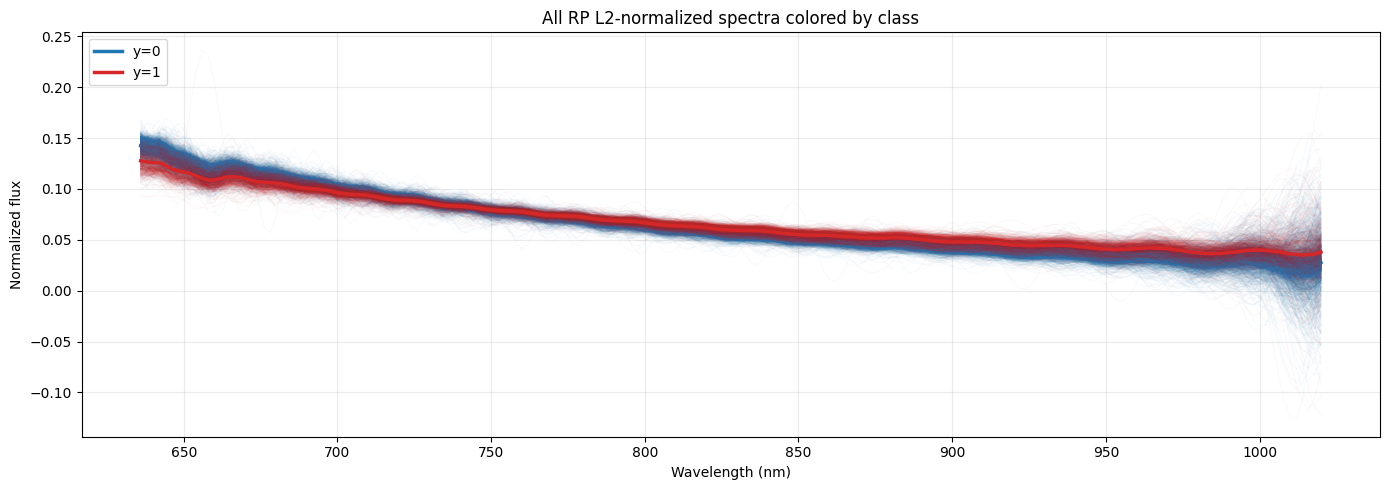

In [78]:
plt.rcParams["text.usetex"] = False

fig, ax = plt.subplots(figsize=(14, 5))
for cls in sorted(df_rp_sampled["y"].dropna().unique()):
    rows = df_rp_sampled[df_rp_sampled["y"] == cls]
    X = rows[rp_cols].to_numpy(dtype=float)
    for row in X:
        ax.plot(wl_rp, row, color=class_colors.get(int(cls), "#7f7f7f"), alpha=0.03, linewidth=0.8)
    mean_row = np.nanmean(X, axis=0)
    ax.plot(wl_rp, mean_row, color=class_colors.get(int(cls), "#7f7f7f"), linewidth=2.5, label=class_labels.get(int(cls), str(cls)))

ax.set_title("All RP L2-normalized spectra colored by class")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Normalized flux")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Save raw and L2-normalized outputs

In [79]:
df_bp_sampled_raw.to_csv(BP_RAW_CSV, index=False)
df_rp_sampled_raw.to_csv(RP_RAW_CSV, index=False)
df_bp_sampled.to_csv(BP_SAMPLED_CSV, index=False)
df_rp_sampled.to_csv(RP_SAMPLED_CSV, index=False)

save_manifest({
    "rows": int(len(label_df)),
    "bp_sampled_csv": str(BP_SAMPLED_CSV),
    "rp_sampled_csv": str(RP_SAMPLED_CSV),
    "bp_raw_csv": str(BP_RAW_CSV),
    "rp_raw_csv": str(RP_RAW_CSV),
    "sampling_kind": "separate BP/RP wavelength-domain calibration via gaiaxpy.calibrate",
    "bp_wavelength_min_nm": float(bp_wavelengths[0]),
    "bp_wavelength_max_nm": float(bp_wavelengths[-1]),
    "bp_wavelength_bins": int(len(bp_wavelengths)),
    "rp_wavelength_min_nm": float(rp_wavelengths[0]),
    "rp_wavelength_max_nm": float(rp_wavelengths[-1]),
    "rp_wavelength_bins": int(len(rp_wavelengths)),
    "cache_vot_dir": str(CACHE_DIR),
    "normalized_outputs": True
})

print("Saved raw:", BP_RAW_CSV)
print("Saved raw:", RP_RAW_CSV)
print("Saved L2:", BP_SAMPLED_CSV)
print("Saved L2:", RP_SAMPLED_CSV)

Saved raw: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/bp_sampled_spectra_raw.csv
Saved raw: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/rp_sampled_spectra_raw.csv
Saved L2: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/bp_sampled_spectra.csv
Saved L2: /Users/erikak/Documents/uni/bakalauras/kodas/bp_rp_basis_experiment/data/rp_sampled_spectra.csv
